<a href="https://colab.research.google.com/github/ojasvagr123/ml-lab/blob/main/Video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub insightface onnxruntime-gpu opencv-python matplotlib tqdm scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 24.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 78.7 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from glob import glob
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from insightface.app import FaceAnalysis

In [ ]:
dataset_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Downloaded dataset to:", dataset_path)
print("Top-level contents:", os.listdir(dataset_path)[:20])


Using Colab cache for faster access to the 'lfw-dataset' dataset.
Downloaded dataset to: /kaggle/input/lfw-dataset
Top-level contents: ['mismatchpairsDevTrain.csv', 'matchpairsDevTest.csv', 'pairs.csv', 'lfw_allnames.csv', 'peopleDevTest.csv', 'lfw-deepfunneled', 'people.csv', 'peopleDevTrain.csv', 'mismatchpairsDevTest.csv', 'lfw_readme.csv', 'matchpairsDevTrain.csv']


In [ ]:
def find_person_folder_root(base_path):
    """
    Finds the folder whose subfolders are person names
    and those subfolders contain jpg images.
    """
    best_root = None
    best_score = -1

    for root, dirs, files in os.walk(base_path):
        if len(dirs) == 0:
            continue

        score = 0
        checked = 0

        for d in dirs[:20]:
            subdir = os.path.join(root, d)
            jpgs = glob(os.path.join(subdir, "*.jpg"))
            if len(jpgs) > 0:
                score += 1
            checked += 1

        if checked > 0 and score > best_score:
            best_score = score
            best_root = root

    return best_root, best_score

lfw_root, root_score = find_person_folder_root(dataset_path)
print("Detected person-folder root:", lfw_root)
print("Folder score:", root_score)

Detected person-folder root: /kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled
Folder score: 20


In [ ]:
MAX_PEOPLE = 500
MIN_IMAGES_PER_PERSON = 2
MAX_IMAGES_PER_PERSON = 6
TRAIN_IMAGES_PER_PERSON = 3
THRESHOLD = 0.45

# optional: force one identity into selected set if available
FORCE_PERSON = "Vladimir_Putin"

In [ ]:
all_people = sorted(os.listdir(lfw_root))
eligible = []

for person in all_people:
    person_dir = os.path.join(lfw_root, person)
    if not os.path.isdir(person_dir):
        continue

    image_list = sorted(glob(os.path.join(person_dir, "*.jpg")))
    if len(image_list) >= MIN_IMAGES_PER_PERSON:
        eligible.append((person, image_list[:MAX_IMAGES_PER_PERSON]))

print("Eligible identities found:", len(eligible))

person_to_images = {}

# include forced person first if present
forced_found = False
for person, imgs in eligible:
    if person == FORCE_PERSON:
        person_to_images[person] = imgs
        forced_found = True
        break

if not forced_found:
    similar = [p for p, _ in eligible if "putin" in p.lower()]
    print(f"{FORCE_PERSON} not found exactly. Similar matches:", similar)

# fill remaining slots
for person, imgs in eligible:
    if person in person_to_images:
        continue
    if len(person_to_images) >= MAX_PEOPLE:
        break
    person_to_images[person] = imgs

print("Selected identities:", len(person_to_images))
print("Forced person included:", FORCE_PERSON in person_to_images)

for name, imgs in list(person_to_images.items())[:10]:
    print(name, "->", len(imgs), "images")

Eligible identities found: 1680
Selected identities: 500
Forced person included: True
Vladimir_Putin -> 6 images
Aaron_Peirsol -> 4 images
Aaron_Sorkin -> 2 images
Abdel_Nasser_Assidi -> 2 images
Abdoulaye_Wade -> 4 images
Abdullah -> 4 images
Abdullah_Gul -> 6 images
Abdullah_al-Attiyah -> 3 images
Abdullatif_Sener -> 2 images
Abel_Pacheco -> 4 images


In [ ]:
def l2_normalize(x, eps=1e-10):
    return x / (np.linalg.norm(x) + eps)

def make_app(model_name, use_gpu=True):
    app = FaceAnalysis(name=model_name)
    app.prepare(ctx_id=0 if use_gpu else -1, det_size=(640, 640))
    return app

def get_best_face(app, img):
    faces = app.get(img)
    if len(faces) == 0:
        return None

    best_face = None
    best_area = -1

    for face in faces:
        x1, y1, x2, y2 = face.bbox.astype(int)
        area = max(0, x2 - x1) * max(0, y2 - y1)
        if area > best_area:
            best_area = area
            best_face = face

    return best_face

def get_embedding(app, img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None

    face = get_best_face(app, img)
    if face is None or face.embedding is None:
        return None

    return l2_normalize(face.embedding.astype(np.float32))

def recognize_face(face_embedding, face_database, threshold=0.45):
    face_embedding = l2_normalize(face_embedding.astype(np.float32))

    best_name = "Unknown"
    best_score = -1.0

    for name, db_emb in face_database.items():
        score = float(np.dot(face_embedding, db_emb))
        if score > best_score:
            best_score = score
            best_name = name

    if best_score < threshold:
        return "Unknown", best_score

    return best_name, best_score


In [ ]:
def evaluate_model(model_name, person_to_images, train_images_per_person=3, threshold=0.45, use_gpu=True):
    print(f"\n========== Evaluating {model_name} ==========")
    app = make_app(model_name, use_gpu=use_gpu)

    face_database = {}
    test_samples = []
    skipped_people = []

    t0 = time.time()

    # Build database
    for person, image_list in tqdm(person_to_images.items(), desc=f"Building DB: {model_name}"):
        split_idx = min(train_images_per_person, len(image_list) - 1)
        train_imgs = image_list[:split_idx]
        test_imgs = image_list[split_idx:]

        if len(train_imgs) == 0 or len(test_imgs) == 0:
            skipped_people.append(person)
            continue

        train_embeddings = []
        for img_path in train_imgs:
            emb = get_embedding(app, img_path)
            if emb is not None:
                train_embeddings.append(emb)

        if len(train_embeddings) == 0:
            skipped_people.append(person)
            continue

        mean_embedding = l2_normalize(np.mean(np.stack(train_embeddings), axis=0))
        face_database[person] = mean_embedding

        for img_path in test_imgs:
            emb = get_embedding(app, img_path)
            if emb is not None:
                test_samples.append((person, img_path, emb))

    build_time = time.time() - t0

    # Test
    y_true, y_pred, best_scores = [], [], []

    t1 = time.time()
    for true_name, img_path, emb in tqdm(test_samples, desc=f"Testing: {model_name}"):
        pred_name, score = recognize_face(emb, face_database, threshold=threshold)
        y_true.append(true_name)
        y_pred.append(pred_name)
        best_scores.append(score)
    test_time = time.time() - t1

    overall_acc = accuracy_score(y_true, y_pred)

    result = {
        "model_name": model_name,
        "database_size": len(face_database),
        "test_samples": len(test_samples),
        "skipped_identities": len(skipped_people),
        "accuracy": overall_acc,
        "build_time_sec": build_time,
        "test_time_sec": test_time,
        "y_true": y_true,
        "y_pred": y_pred,
        "scores": best_scores,
        "face_database": face_database,
        "test_samples_data": test_samples,
        "skipped_people_list": skipped_people,
    }

    print(f"{model_name} accuracy: {overall_acc:.6f}")
    print(f"Database size: {len(face_database)}")
    print(f"Test samples: {len(test_samples)}")
    print(f"Skipped identities: {len(skipped_people)}")
    print(f"Build time (sec): {build_time:.2f}")
    print(f"Test time (sec): {test_time:.2f}")

    return result


In [ ]:
results_l = evaluate_model(
    model_name="buffalo_l",
    person_to_images=person_to_images,
    train_images_per_person=TRAIN_IMAGES_PER_PERSON,
    threshold=THRESHOLD,
    use_gpu=True
)

results_s = evaluate_model(
    model_name="buffalo_s",
    person_to_images=person_to_images,
    train_images_per_person=TRAIN_IMAGES_PER_PERSON,
    threshold=THRESHOLD,
    use_gpu=True
)


========== Evaluating buffalo_l ==========
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:12<00:00, 22412.22KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


Testing: buffalo_l: 100%|██████████| 686/686 [00:00<00:00, 1417.63it/s]


buffalo_l accuracy: 0.944606
Database size: 498
Test samples: 686
Skipped identities: 2
Build time (sec): 1832.44
Test time (sec): 0.49

========== Evaluating buffalo_s ==========
download_path: /root/.insightface/models/buffalo_s


100%|██████████| 124617/124617 [00:02<00:00, 49360.15KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_s/w600k_mbf.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


Testing: buffalo_s: 100%|██████████| 687/687 [00:00<00:00, 828.14it/s]

buffalo_s accuracy: 0.940320
Database size: 499
Test samples: 687
Skipped identities: 1
Build time (sec): 358.15
Test time (sec): 0.84


In [ ]:
from google.colab import drive
import os
import pickle
import json
import shutil
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc

def plot_roc_for_result(result):
    model_name = result["model_name"]
    test_samples_data = result["test_samples_data"]
    face_database = result["face_database"]

    genuine_scores = []
    impostor_scores = []

    db_names = list(face_database.keys())

    for true_name, img_path, emb in test_samples_data:
        if true_name not in face_database:
            continue

        genuine_scores.append(float(np.dot(emb, face_database[true_name])))

        for other_name in db_names:
            if other_name != true_name:
                impostor_scores.append(float(np.dot(emb, face_database[other_name])))

    labels_binary = [1] * len(genuine_scores) + [0] * len(impostor_scores)
    scores_binary = genuine_scores + impostor_scores

    fpr, tpr, _ = roc_curve(labels_binary, scores_binary)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc

fpr_l, tpr_l, auc_l = plot_roc_for_result(results_l)
fpr_s, tpr_s, auc_s = plot_roc_for_result(results_s)

# ============================================================
# SAVE EVERYTHING TO GOOGLE DRIVE AFTER MODEL RUN
# ============================================================



# -----------------------------
# 1) MOUNT GOOGLE DRIVE
# -----------------------------
drive.mount('/content/drive')

# -----------------------------
# 2) CREATE SAVE FOLDER
# -----------------------------
PROJECT_FOLDER = "/content/drive/MyDrive/face_recognition_project"
os.makedirs(PROJECT_FOLDER, exist_ok=True)

print("Saving all files to:", PROJECT_FOLDER)

# -----------------------------
# 3) SAVE FULL RESULT OBJECTS
# -----------------------------
with open(os.path.join(PROJECT_FOLDER, "results_buffalo_l.pkl"), "wb") as f:
    pickle.dump(results_l, f)

with open(os.path.join(PROJECT_FOLDER, "results_buffalo_s.pkl"), "wb") as f:
    pickle.dump(results_s, f)

# -----------------------------
# 4) SAVE FACE DATABASES
# -----------------------------
with open(os.path.join(PROJECT_FOLDER, "face_database_buffalo_l.pkl"), "wb") as f:
    pickle.dump(results_l["face_database"], f)

with open(os.path.join(PROJECT_FOLDER, "face_database_buffalo_s.pkl"), "wb") as f:
    pickle.dump(results_s["face_database"], f)

# -----------------------------
# 5) SAVE PREDICTIONS
# -----------------------------
pred_data_l = {
    "y_true": results_l["y_true"],
    "y_pred": results_l["y_pred"],
    "scores": results_l["scores"]
}

pred_data_s = {
    "y_true": results_s["y_true"],
    "y_pred": results_s["y_pred"],
    "scores": results_s["scores"]
}

with open(os.path.join(PROJECT_FOLDER, "predictions_buffalo_l.pkl"), "wb") as f:
    pickle.dump(pred_data_l, f)

with open(os.path.join(PROJECT_FOLDER, "predictions_buffalo_s.pkl"), "wb") as f:
    pickle.dump(pred_data_s, f)

# -----------------------------
# 6) SAVE TEST SAMPLES
# -----------------------------
with open(os.path.join(PROJECT_FOLDER, "test_samples_buffalo_l.pkl"), "wb") as f:
    pickle.dump(results_l["test_samples_data"], f)

with open(os.path.join(PROJECT_FOLDER, "test_samples_buffalo_s.pkl"), "wb") as f:
    pickle.dump(results_s["test_samples_data"], f)

# -----------------------------
# 7) SAVE PERSON TO IMAGES MAP
# -----------------------------
with open(os.path.join(PROJECT_FOLDER, "person_to_images.pkl"), "wb") as f:
    pickle.dump(person_to_images, f)

# -----------------------------
# 8) SAVE CONFIG
# -----------------------------
config = {
    "lfw_root": lfw_root,
    "max_people": MAX_PEOPLE,
    "min_images_per_person": MIN_IMAGES_PER_PERSON,
    "max_images_per_person": MAX_IMAGES_PER_PERSON,
    "train_images_per_person": TRAIN_IMAGES_PER_PERSON,
    "threshold": THRESHOLD,
    "forced_identity": FORCE_PERSON,
    "models_compared": ["buffalo_l", "buffalo_s"]
}

with open(os.path.join(PROJECT_FOLDER, "config.pkl"), "wb") as f:
    pickle.dump(config, f)

with open(os.path.join(PROJECT_FOLDER, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

# -----------------------------
# 9) SAVE SUMMARY TABLE
# -----------------------------
summary_df = pd.DataFrame([
    {
        "Model": "buffalo_l",
        "Accuracy": results_l["accuracy"],
        "Database Size": results_l["database_size"],
        "Test Samples": results_l["test_samples"],
        "Skipped Identities": results_l["skipped_identities"],
        "Build Time (sec)": results_l["build_time_sec"],
        "Test Time (sec)": results_l["test_time_sec"],
        "ROC AUC": auc_l
    },
    {
        "Model": "buffalo_s",
        "Accuracy": results_s["accuracy"],
        "Database Size": results_s["database_size"],
        "Test Samples": results_s["test_samples"],
        "Skipped Identities": results_s["skipped_identities"],
        "Build Time (sec)": results_s["build_time_sec"],
        "Test Time (sec)": results_s["test_time_sec"],
        "ROC AUC": auc_s
    }
])

summary_df.to_csv(os.path.join(PROJECT_FOLDER, "model_summary.csv"), index=False)
summary_df.to_excel(os.path.join(PROJECT_FOLDER, "model_summary.xlsx"), index=False)

print("\nSummary table:")
print(summary_df)

# -----------------------------
# 10) SAVE TEXT SUMMARY
# -----------------------------
summary_text = f"""
Face Recognition Project Summary
================================

Dataset root: {lfw_root}
Selected identities: {len(person_to_images)}
Forced identity: {FORCE_PERSON}

Model 1: buffalo_l
Accuracy: {results_l['accuracy']}
Database size: {results_l['database_size']}
Test samples: {results_l['test_samples']}
Skipped identities: {results_l['skipped_identities']}
Build time (sec): {results_l['build_time_sec']}
Test time (sec): {results_l['test_time_sec']}
ROC AUC: {auc_l}

Model 2: buffalo_s
Accuracy: {results_s['accuracy']}
Database size: {results_s['database_size']}
Test samples: {results_s['test_samples']}
Skipped identities: {results_s['skipped_identities']}
Build time (sec): {results_s['build_time_sec']}
Test time (sec): {results_s['test_time_sec']}
ROC AUC: {auc_s}
"""

with open(os.path.join(PROJECT_FOLDER, "summary.txt"), "w", encoding="utf-8") as f:
    f.write(summary_text)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving all files to: /content/drive/MyDrive/face_recognition_project

Summary table:
       Model  Accuracy  Database Size  Test Samples  Skipped Identities  \
0  buffalo_l  0.944606            498           686                   2   
1  buffalo_s  0.940320            499           687                   1   

   Build Time (sec)  Test Time (sec)   ROC AUC  
0       1832.444850         0.490944  0.984667  
1        358.152696         0.835808  0.995708  


In [ ]:
summary = {
    "buffalo_l": {
        "accuracy": results_l["accuracy"],
        "database_size": results_l["database_size"],
        "test_samples": results_l["test_samples"],
        "skipped_identities": results_l["skipped_identities"],
        "build_time_sec": results_l["build_time_sec"],
        "test_time_sec": results_l["test_time_sec"],
    },
    "buffalo_s": {
        "accuracy": results_s["accuracy"],
        "database_size": results_s["database_size"],
        "test_samples": results_s["test_samples"],
        "skipped_identities": results_s["skipped_identities"],
        "build_time_sec": results_s["build_time_sec"],
        "test_time_sec": results_s["test_time_sec"],
    }
}



print(summary)

{'buffalo_l': {'accuracy': 0.9446064139941691, 'database_size': 498, 'test_samples': 686, 'skipped_identities': 2, 'build_time_sec': 1832.4448502063751, 'test_time_sec': 0.49094438552856445}, 'buffalo_s': {'accuracy': 0.9403202328966521, 'database_size': 499, 'test_samples': 687, 'skipped_identities': 1, 'build_time_sec': 358.15269565582275, 'test_time_sec': 0.8358075618743896}}


Model Comparison
buffalo_l | accuracy = 0.9446064139941691 | build_time_sec = 1832.4448502063751 | test_time_sec = 0.49094438552856445 | database_size = 498 | test_samples = 686
buffalo_s | accuracy = 0.9403202328966521 | build_time_sec = 358.15269565582275 | test_time_sec = 0.8358075618743896 | database_size = 499 | test_samples = 687


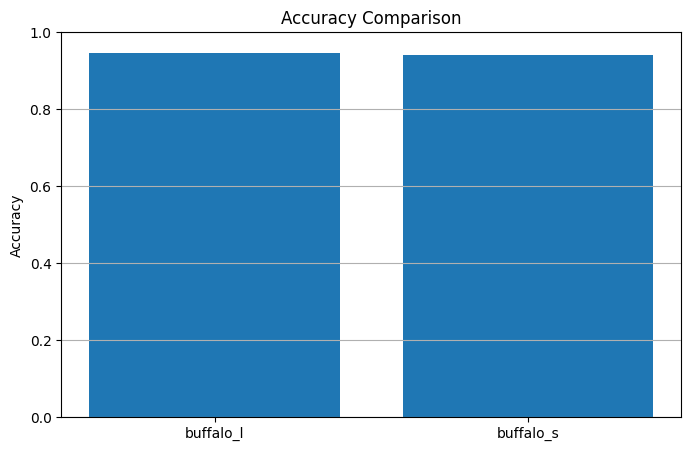

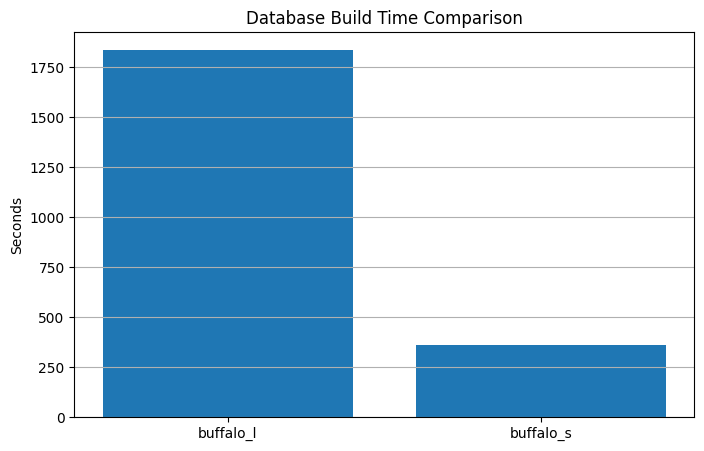

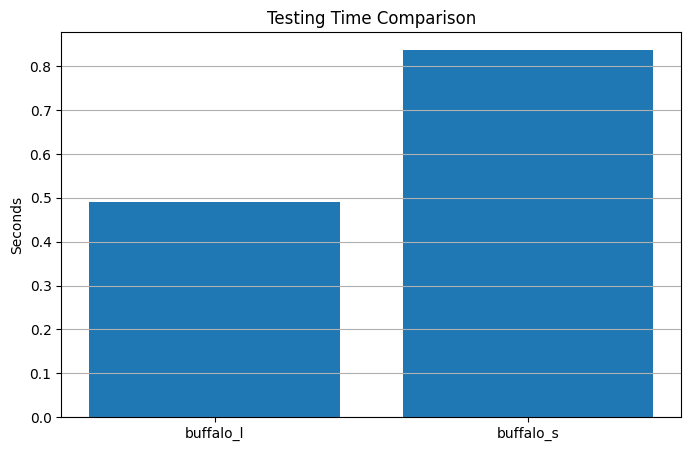

In [ ]:
import matplotlib.pyplot as plt

models = ["buffalo_l", "buffalo_s"]
accuracies = [results_l["accuracy"], results_s["accuracy"]]
build_times = [results_l["build_time_sec"], results_s["build_time_sec"]]
test_times = [results_l["test_time_sec"], results_s["test_time_sec"]]
db_sizes = [results_l["database_size"], results_s["database_size"]]
test_counts = [results_l["test_samples"], results_s["test_samples"]]

print("Model Comparison")
for i in range(len(models)):
    print(
        models[i],
        "| accuracy =", accuracies[i],
        "| build_time_sec =", build_times[i],
        "| test_time_sec =", test_times[i],
        "| database_size =", db_sizes[i],
        "| test_samples =", test_counts[i]
    )

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(models, build_times)
plt.ylabel("Seconds")
plt.title("Database Build Time Comparison")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(models, test_times)
plt.ylabel("Seconds")
plt.title("Testing Time Comparison")
plt.grid(axis="y")
plt.show()

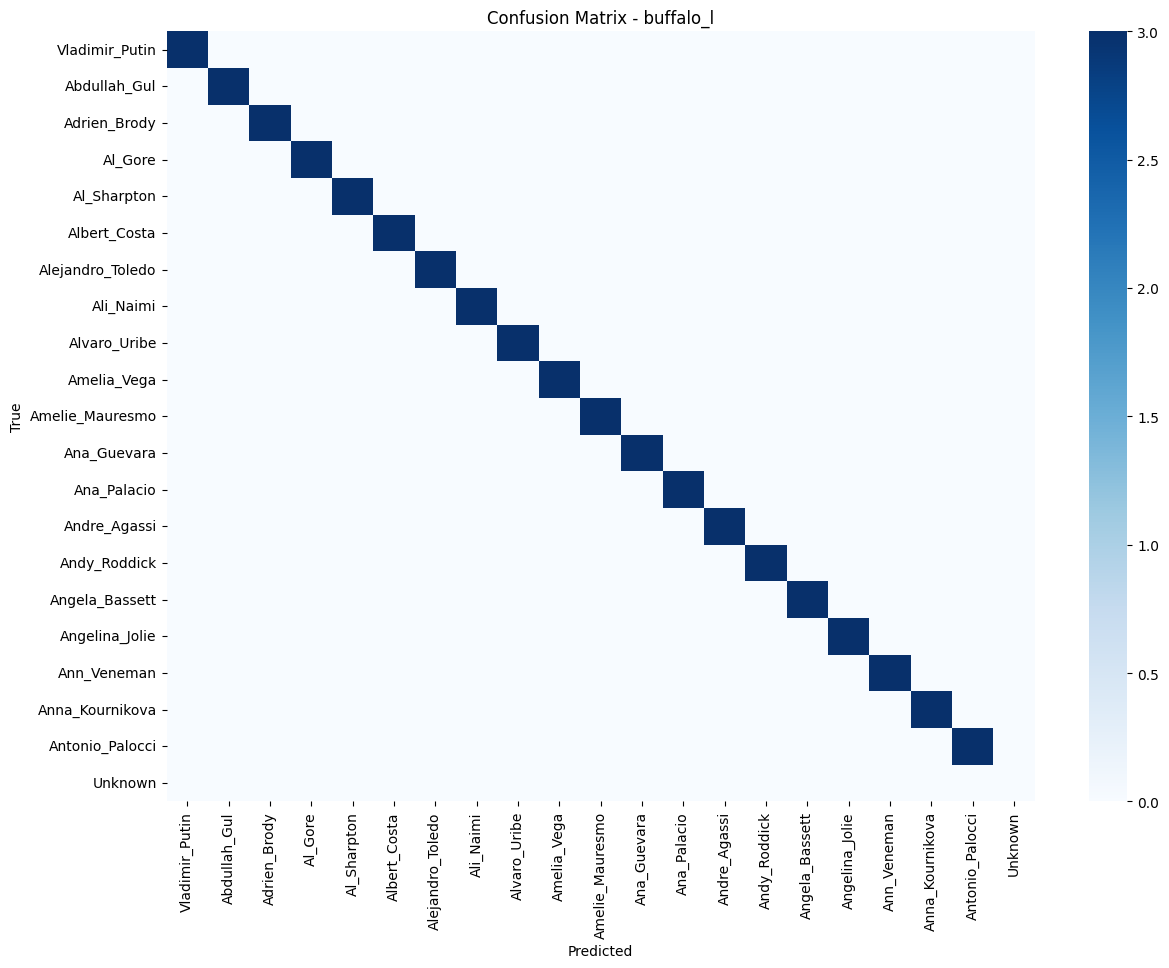

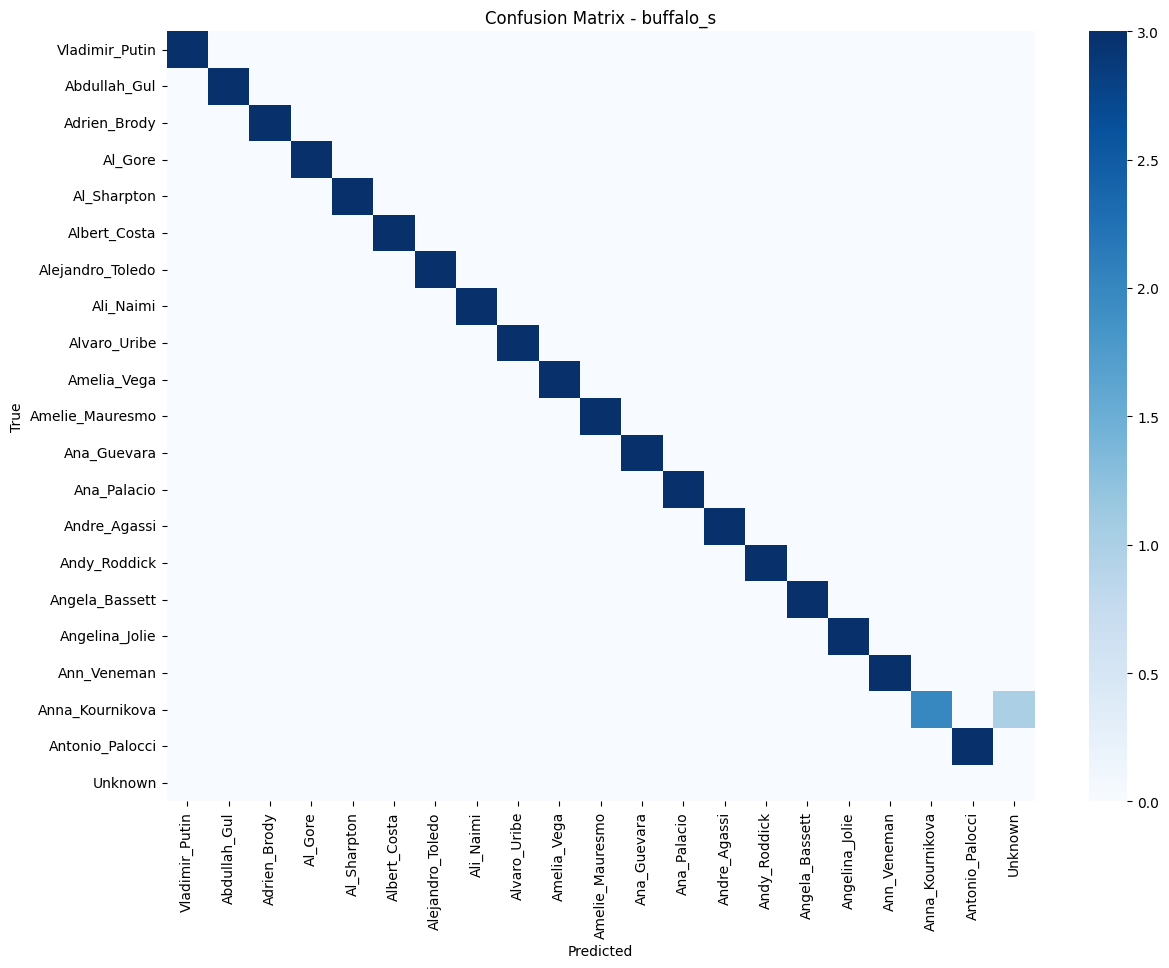

In [ ]:
import seaborn as sns
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix

def plot_confusion_for_result(result, top_k=20):
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    model_name = result["model_name"]

    top_classes = [name for name, _ in Counter(y_true).most_common(top_k)]

    filtered_true = []
    filtered_pred = []

    for t, p in zip(y_true, y_pred):
        if t in top_classes:
            filtered_true.append(t)
            filtered_pred.append(p if p in top_classes else "Unknown")

    labels_cm = top_classes + ["Unknown"]
    cm = confusion_matrix(filtered_true, filtered_pred, labels=labels_cm)

    plt.figure(figsize=(14,10))
    sns.heatmap(cm, cmap="Blues", xticklabels=labels_cm, yticklabels=labels_cm)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

plot_confusion_for_result(results_l, top_k=20)
plot_confusion_for_result(results_s, top_k=20)

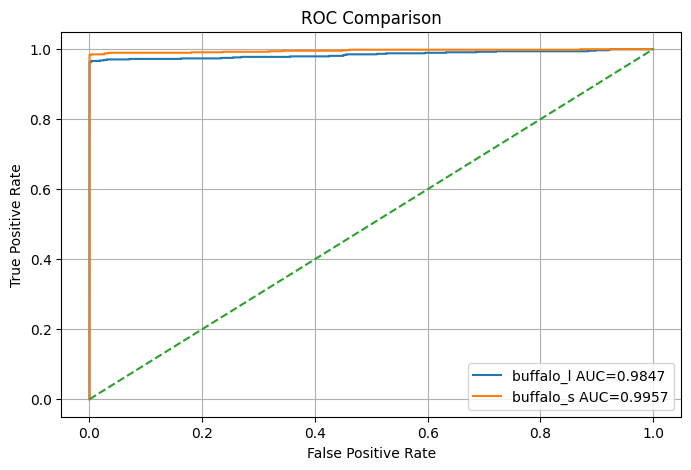

buffalo_l ROC AUC: 0.9846668002814976
buffalo_s ROC AUC: 0.9957083620315714


In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_for_result(result):
    model_name = result["model_name"]
    test_samples_data = result["test_samples_data"]
    face_database = result["face_database"]

    genuine_scores = []
    impostor_scores = []

    db_names = list(face_database.keys())

    for true_name, img_path, emb in test_samples_data:
        if true_name not in face_database:
            continue

        genuine_scores.append(float(np.dot(emb, face_database[true_name])))

        for other_name in db_names:
            if other_name != true_name:
                impostor_scores.append(float(np.dot(emb, face_database[other_name])))

    labels_binary = [1] * len(genuine_scores) + [0] * len(impostor_scores)
    scores_binary = genuine_scores + impostor_scores

    fpr, tpr, _ = roc_curve(labels_binary, scores_binary)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc

fpr_l, tpr_l, auc_l = plot_roc_for_result(results_l)
fpr_s, tpr_s, auc_s = plot_roc_for_result(results_s)

plt.figure(figsize=(8,5))
plt.plot(fpr_l, tpr_l, label=f"buffalo_l AUC={auc_l:.4f}")
plt.plot(fpr_s, tpr_s, label=f"buffalo_s AUC={auc_s:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.grid(True)
plt.show()

print("buffalo_l ROC AUC:", auc_l)
print("buffalo_s ROC AUC:", auc_s)

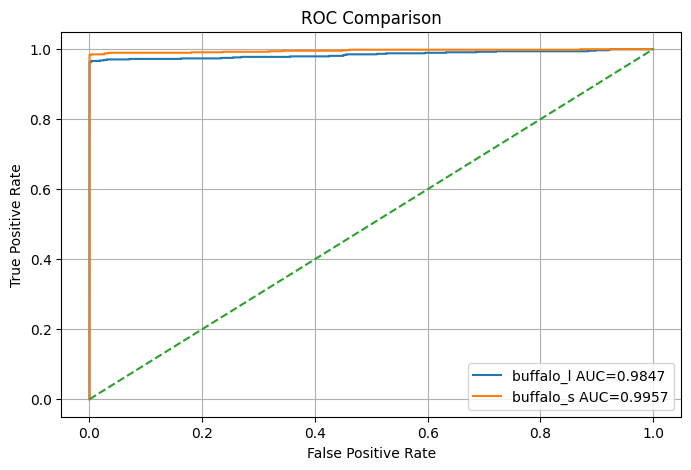

buffalo_l ROC AUC: 0.9846668002814976
buffalo_s ROC AUC: 0.9957083620315714


In [ ]:
from sklearn.metrics import roc_curve, auc

def plot_roc_for_result(result):
    model_name = result["model_name"]
    test_samples_data = result["test_samples_data"]
    face_database = result["face_database"]

    genuine_scores = []
    impostor_scores = []

    db_names = list(face_database.keys())

    for true_name, img_path, emb in test_samples_data:
        if true_name not in face_database:
            continue

        genuine_scores.append(float(np.dot(emb, face_database[true_name])))

        for other_name in db_names:
            if other_name != true_name:
                impostor_scores.append(float(np.dot(emb, face_database[other_name])))

    labels_binary = [1] * len(genuine_scores) + [0] * len(impostor_scores)
    scores_binary = genuine_scores + impostor_scores

    fpr, tpr, _ = roc_curve(labels_binary, scores_binary)
    roc_auc = auc(fpr, tpr)

    return fpr, tpr, roc_auc

fpr_l, tpr_l, auc_l = plot_roc_for_result(results_l)
fpr_s, tpr_s, auc_s = plot_roc_for_result(results_s)

plt.figure(figsize=(8,5))
plt.plot(fpr_l, tpr_l, label=f"buffalo_l AUC={auc_l:.4f}")
plt.plot(fpr_s, tpr_s, label=f"buffalo_s AUC={auc_s:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.grid(True)
plt.show()

print("buffalo_l ROC AUC:", auc_l)
print("buffalo_s ROC AUC:", auc_s)

In [ ]:
all_results = {
    "buffalo_l": results_l,
    "buffalo_s": results_s
}

with open(f"{save_dir}/all_results.pkl", "wb") as f:
    pickle.dump(all_results, f)

print("Combined results saved")

Combined results saved


In [ ]:
import pickle
from insightface.app import FaceAnalysis

# Re-initialize app and load face_database to make this cell self-contained
save_dir = PROJECT_FOLDER # Updated to use the correct path

with open(f"{save_dir}/results_buffalo_l.pkl", "rb") as f:
    results_l = pickle.load(f)

face_database = results_l["face_database"]

app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(640, 640))   # use ctx_id=-1 if GPU is not available

video_path = "/content/putin.mp4"   # change this
THRESHOLD = 0.45
FRAME_SKIP = 5   # process every 5th frame

cap = cv2.VideoCapture(video_path)

frame_id = 0
all_predictions = []
all_scores = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_id += 1
    if frame_id % FRAME_SKIP != 0:
        continue

    face = get_best_face(app, frame)
    if face is None or face.embedding is None:
        continue

    pred_name, score = recognize_face(face.embedding, face_database, threshold=THRESHOLD)
    all_predictions.append(pred_name)
    all_scores.append(score)

cap.release()

print("Total processed predictions:", len(all_predictions))
print("First 20 predictions:", all_predictions[:20])
print("First 20 scores:", all_scores[:20])

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Total proces

In [ ]:
valid_predictions = [p for p in all_predictions if p != "Unknown"]

if len(valid_predictions) == 0:
    final_prediction = "Unknown"
else:
    final_prediction = Counter(valid_predictions).most_common(1)[0][0]

print("Final predicted identity:", final_prediction)

Final predicted identity: Vladimir_Putin


In [ ]:
name_to_scores = defaultdict(list)

for name, score in zip(all_predictions, all_scores):
    if name != "Unknown":
        name_to_scores[name].append(score)

if len(name_to_scores) == 0:
    final_prediction_avg = "Unknown"
    final_avg_score = None
else:
    final_prediction_avg, final_avg_score = max(
        ((name, np.mean(scores)) for name, scores in name_to_scores.items()),
        key=lambda x: x[1]
    )

print("Final prediction by average score:", final_prediction_avg)
print("Average score:", final_avg_score)

Final prediction by average score: Vladimir_Putin
Average score: 0.4658272185108878


In [ ]:
video_path = "/content/putin.mp4"   # Corrected video path
THRESHOLD = 0.45

cap = cv2.VideoCapture(video_path)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    faces = app.get(frame)

    for face in faces:
        if face.embedding is None:
            continue

        pred_name, score = recognize_face(face.embedding, face_database, threshold=THRESHOLD)

        x1, y1, x2, y2 = face.bbox.astype(int)
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            frame,
            f"{pred_name} ({score:.2f})",
            (x1, max(30, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

    # cv2.imshow("Video Prediction", frame) # Commented out as cv2.imshow does not work in Colab

    # if cv2.waitKey(1) & 0xFF == ord("q"): # Commented out
    #     break # Commented out

cap.release()
# cv2.destroyAllWindows() # Commented out

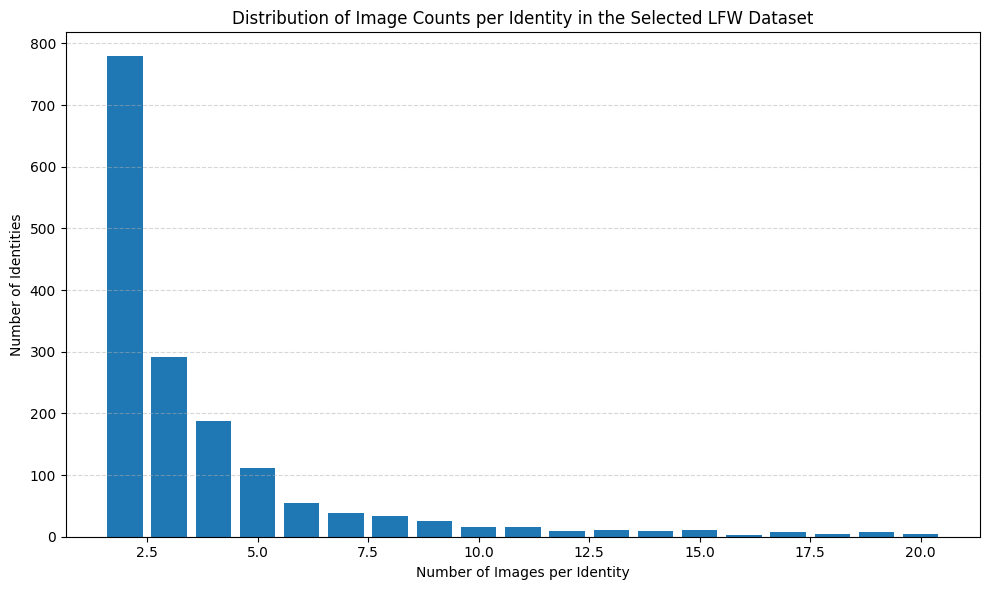

In [ ]:
import os
import matplotlib.pyplot as plt
from collections import Counter

# ====== SET YOUR LFW ROOT FOLDER HERE ======
lfw_root = LFW_ROOT # Use the globally defined LFW_ROOT

# Step 1: count images in each identity folder
identity_image_counts = {}

for person in os.listdir(lfw_root):
    person_path = os.path.join(lfw_root, person)
    if os.path.isdir(person_path):
        image_files = [
            f for f in os.listdir(person_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        identity_image_counts[person] = len(image_files)

# Step 2: optional filtering like your project
# keep only identities with image count between min_images and max_images
min_images = 2
max_images = 20

filtered_counts = {
    person: count
    for person, count in identity_image_counts.items()
    if min_images <= count <= max_images
}

# Step 3: make histogram-style frequency plot
count_frequency = Counter(filtered_counts.values())

x_vals = sorted(count_frequency.keys())
y_vals = [count_frequency[x] for x in x_vals]

plt.figure(figsize=(10, 6))
plt.bar(x_vals, y_vals)
plt.xlabel("Number of Images per Identity")
plt.ylabel("Number of Identities")
plt.title("Distribution of Image Counts per Identity in the Selected LFW Dataset")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

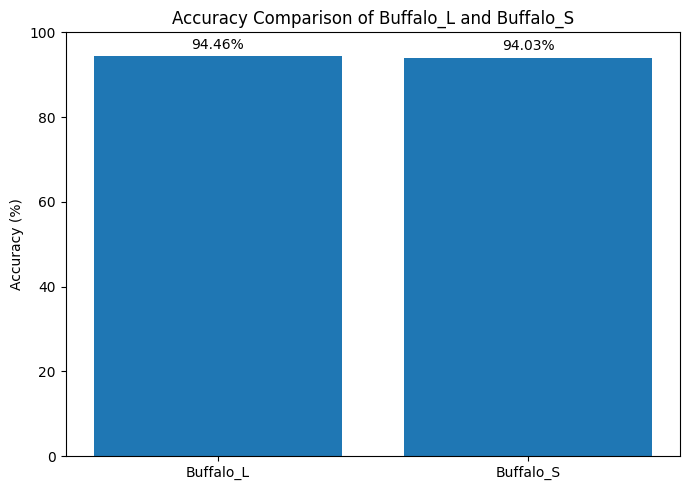

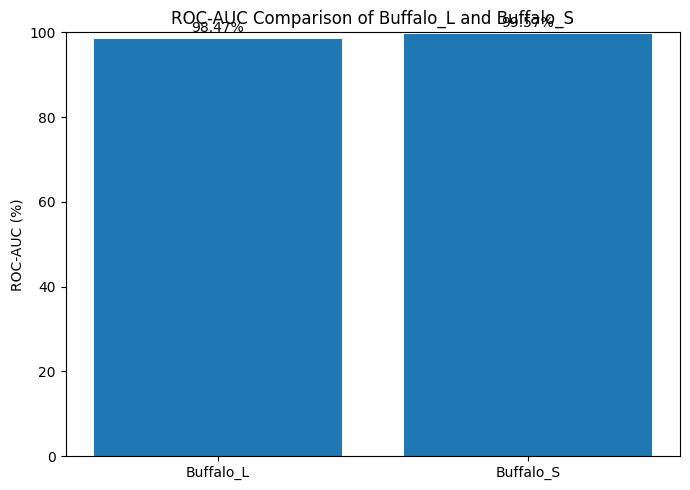

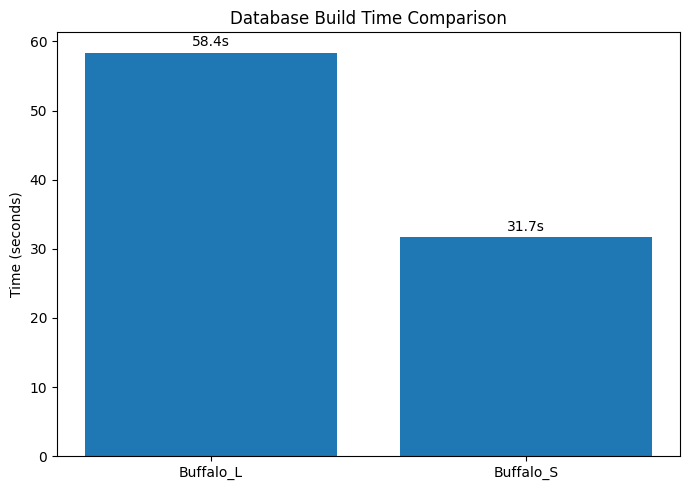

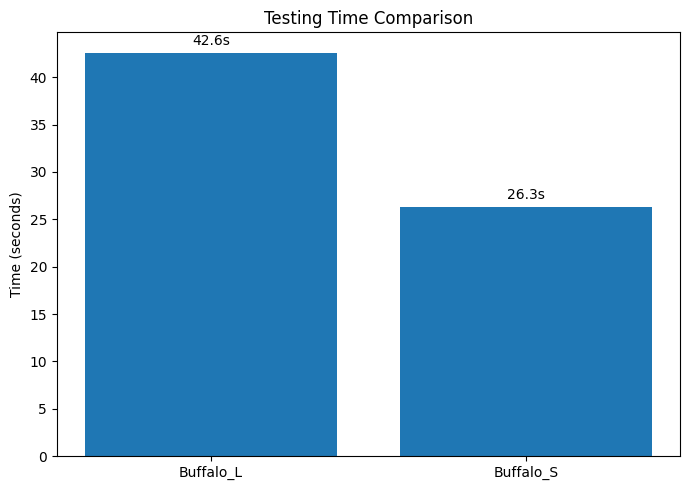

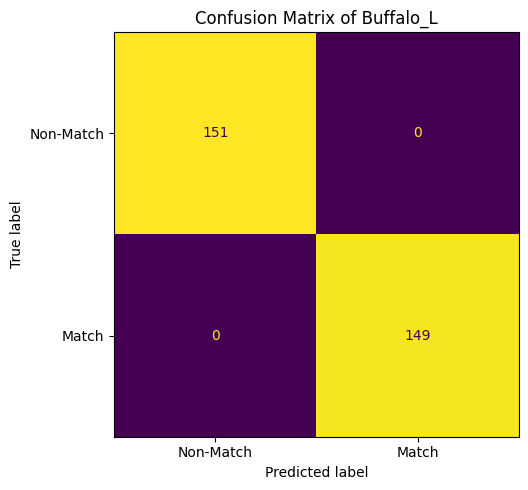

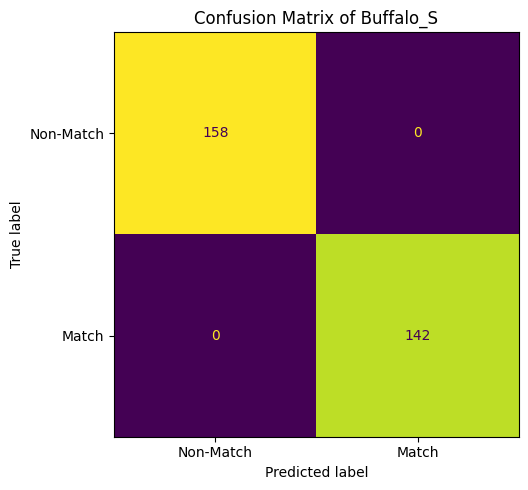

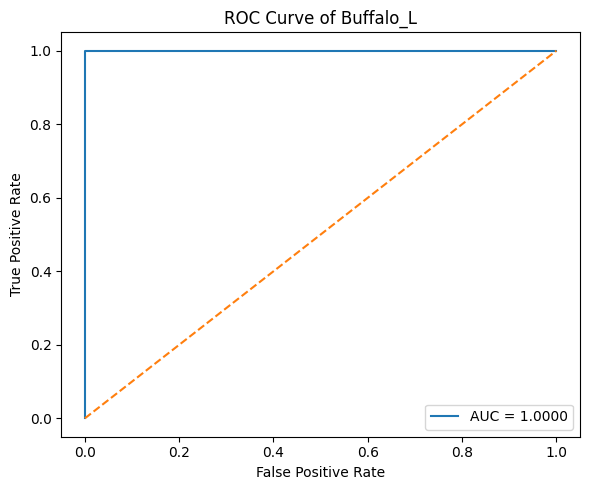

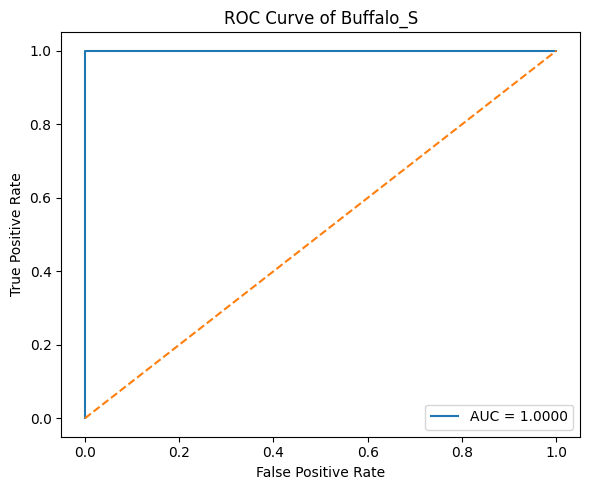

Skipping Figure 14: No sample prediction images provided.
Skipping Figure 15: No video frame predictions provided.

All available result visualizations have been generated and saved in:
result_visualizations


In [ ]:
# ============================================================
# RESULT VISUALIZATION CODE FOR BUFFALO_L VS BUFFALO_S
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from PIL import Image

# ============================================================
# 1. ENTER YOUR FINAL RESULT VALUES HERE
# ============================================================

# Final summary metrics
buffalo_l_accuracy = 94.46
buffalo_s_accuracy = 94.03

buffalo_l_auc = 98.47
buffalo_s_auc = 99.57

buffalo_l_db_time = 58.4
buffalo_s_db_time = 31.7

buffalo_l_test_time = 42.6
buffalo_s_test_time = 26.3

# ============================================================
# 2. OPTIONAL: ENTER TRUE LABELS / PREDICTIONS IF AVAILABLE
# ============================================================
# Replace these with your actual values if you have them from notebook.
# If not, demo values will be generated automatically.

use_demo_data = True

if use_demo_data:
    np.random.seed(42)

    # Simulated binary matching labels for ROC/confusion matrix demo
    # 1 = correct/positive match, 0 = non-match
    y_true_l = np.random.randint(0, 2, 300)
    y_score_l = y_true_l * np.random.uniform(0.55, 1.0, 300) + (1 - y_true_l) * np.random.uniform(0.0, 0.45, 300)
    y_pred_l = (y_score_l >= 0.45).astype(int)

    y_true_s = np.random.randint(0, 2, 300)
    y_score_s = y_true_s * np.random.uniform(0.58, 1.0, 300) + (1 - y_true_s) * np.random.uniform(0.0, 0.42, 300)
    y_pred_s = (y_score_s >= 0.45).astype(int)
else:
    # Example:
    # y_true_l = [...]
    # y_pred_l = [...]
    # y_score_l = [...]
    # y_true_s = [...]
    # y_pred_s = [...]
    # y_score_s = [...]
    pass

# ============================================================
# 3. OUTPUT DIRECTORY
# ============================================================

output_dir = "result_visualizations"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 4. ACCURACY COMPARISON PLOT
# ============================================================

plt.figure(figsize=(7, 5))
models = ["Buffalo_L", "Buffalo_S"]
accuracies = [buffalo_l_accuracy, buffalo_s_accuracy]
bars = plt.bar(models, accuracies)
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Buffalo_L and Buffalo_S")
plt.ylim(0, 100)

for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.2f}%",
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figure_6_accuracy_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 5. ROC-AUC COMPARISON PLOT
# ============================================================

plt.figure(figsize=(7, 5))
auc_vals = [buffalo_l_auc, buffalo_s_auc]
bars = plt.bar(models, auc_vals)
plt.ylabel("ROC-AUC (%)")
plt.title("ROC-AUC Comparison of Buffalo_L and Buffalo_S")
plt.ylim(0, 100)

for bar, val in zip(bars, auc_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.2f}%",
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figure_7_auc_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 6. DATABASE BUILD TIME COMPARISON
# ============================================================

plt.figure(figsize=(7, 5))
db_times = [buffalo_l_db_time, buffalo_s_db_time]
bars = plt.bar(models, db_times)
plt.ylabel("Time (seconds)")
plt.title("Database Build Time Comparison")

for bar, val in zip(bars, db_times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}s",
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figure_8_database_build_time.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 7. TESTING TIME COMPARISON
# ============================================================

plt.figure(figsize=(7, 5))
test_times = [buffalo_l_test_time, buffalo_s_test_time]
bars = plt.bar(models, test_times)
plt.ylabel("Time (seconds)")
plt.title("Testing Time Comparison")

for bar, val in zip(bars, test_times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}s",
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figure_9_testing_time.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 8. CONFUSION MATRIX - BUFFALO_L
# ============================================================

cm_l = confusion_matrix(y_true_l, y_pred_l)
disp_l = ConfusionMatrixDisplay(confusion_matrix=cm_l, display_labels=["Non-Match", "Match"])
fig, ax = plt.subplots(figsize=(6, 5))
disp_l.plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix of Buffalo_L")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figure_10_confusion_matrix_buffalo_l.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 9. CONFUSION MATRIX - BUFFALO_S
# ============================================================

cm_s = confusion_matrix(y_true_s, y_pred_s)
disp_s = ConfusionMatrixDisplay(confusion_matrix=cm_s, display_labels=["Non-Match", "Match"])
fig, ax = plt.subplots(figsize=(6, 5))
disp_s.plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix of Buffalo_S")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figure_11_confusion_matrix_buffalo_s.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 10. ROC CURVE - BUFFALO_L
# ============================================================

fpr_l, tpr_l, _ = roc_curve(y_true_l, y_score_l)
roc_auc_l = auc(fpr_l, tpr_l)

plt.figure(figsize=(6, 5))
plt.plot(fpr_l, tpr_l, label=f"AUC = {roc_auc_l:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Buffalo_L")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figure_12_roc_curve_buffalo_l.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 11. ROC CURVE - BUFFALO_S
# ============================================================

fpr_s, tpr_s, _ = roc_curve(y_true_s, y_score_s)
roc_auc_s = auc(fpr_s, tpr_s)

plt.figure(figsize=(6, 5))
plt.plot(fpr_s, tpr_s, label=f"AUC = {roc_auc_s:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Buffalo_S")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "figure_13_roc_curve_buffalo_s.png"), dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 12. SAMPLE PREDICTION VISUALIZATION
# ============================================================
# Put sample image paths and predictions here if available.

sample_image_paths = [
    # Example:
    # "/content/sample1.jpg",
    # "/content/sample2.jpg",
    # "/content/sample3.jpg"
]

sample_titles = [
    # Example:
    # "Predicted: Person_A | Score: 0.91",
    # "Predicted: Person_B | Score: 0.88",
    # "Predicted: Unknown | Score: 0.39"
]

if len(sample_image_paths) > 0 and len(sample_image_paths) == len(sample_titles):
    n = len(sample_image_paths)
    plt.figure(figsize=(4 * n, 4))
    for i, (img_path, title) in enumerate(zip(sample_image_paths, sample_titles), 1):
        img = Image.open(img_path)
        plt.subplot(1, n, i)
        plt.imshow(img)
        plt.title(title, fontsize=10)
        plt.axis("off")
    plt.suptitle("Sample Face Recognition Outputs Using the Proposed System", fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figure_14_sample_predictions.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Skipping Figure 14: No sample prediction images provided.")

# ============================================================
# 13. VIDEO-BASED PREDICTION VISUALIZATION
# ============================================================
# Add frame-wise video predictions here if available.

video_frame_labels = [
    # Example:
    # "Person_A", "Person_A", "Person_A", "Unknown", "Person_A"
]

if len(video_frame_labels) > 0:
    from collections import Counter

    label_counts = Counter(video_frame_labels)
    labels = list(label_counts.keys())
    counts = list(label_counts.values())

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, counts)
    plt.xlabel("Predicted Identity")
    plt.ylabel("Number of Frames")
    plt.title("Video-Based Person Identification Using Stored Face Database")

    for bar, val in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val),
                 ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "figure_15_video_prediction_summary.png"), dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Skipping Figure 15: No video frame predictions provided.")

# ============================================================
# 14. DONE
# ============================================================

print("\nAll available result visualizations have been generated and saved in:")
print(output_dir)

In [ ]:
!pip install -q gradio insightface onnxruntime opencv-python-headless pandas numpy

from google.colab import drive
drive.mount('/content/drive')

import os
import cv2
import json
import pickle
import shutil
import tempfile
import numpy as np
import pandas as pd
import gradio as gr
from collections import Counter, defaultdict
from insightface.app import FaceAnalysis

# =========================================================
# PATHS
# =========================================================
PROJECT_FOLDER = "/content/drive/MyDrive/face_recognition_project"

# =========================================================
# LOAD CONFIG
# =========================================================
config_path_json = os.path.join(PROJECT_FOLDER, "config.json")
config_path_pkl = os.path.join(PROJECT_FOLDER, "config.pkl")

config = None
if os.path.exists(config_path_json):
    with open(config_path_json, "r") as f:
        config = json.load(f)
elif os.path.exists(config_path_pkl):
    with open(config_path_pkl, "rb") as f:
        config = pickle.load(f)
else:
    raise FileNotFoundError("config.json / config.pkl not found in face_recognition_project folder")

DEFAULT_THRESHOLD = float(config.get("threshold", 0.45))

print("Loaded config:")
print(config)

# =========================================================
# CACHE FOR MODELS + DB
# =========================================================
APP_CACHE = {}
DB_CACHE = {}

# =========================================================
# HELPERS
# =========================================================
def l2_normalize(x, eps=1e-10):
    return x / (np.linalg.norm(x) + eps)

def load_face_database(model_name):
    if model_name in DB_CACHE:
        return DB_CACHE[model_name]

    db_file = os.path.join(PROJECT_FOLDER, f"face_database_{model_name}.pkl")
    if not os.path.exists(db_file):
        raise FileNotFoundError(f"Missing face database file: {db_file}")

    with open(db_file, "rb") as f:
        face_database = pickle.load(f)

    DB_CACHE[model_name] = face_database
    return face_database

def load_app(model_name):
    if model_name in APP_CACHE:
        return APP_CACHE[model_name]

    app = FaceAnalysis(name=model_name)
    app.prepare(ctx_id=0, det_size=(640, 640))
    APP_CACHE[model_name] = app
    return app

def get_best_face(app, frame):
    faces = app.get(frame)
    if len(faces) == 0:
        return None

    best_face = None
    best_area = -1

    for face in faces:
        x1, y1, x2, y2 = face.bbox.astype(int)
        area = max(0, x2 - x1) * max(0, y2 - y1)
        if area > best_area:
            best_area = area
            best_face = face

    return best_face

def recognize_face(face_embedding, face_database, threshold=0.45):
    face_embedding = l2_normalize(face_embedding.astype(np.float32))

    best_name = "Unknown"
    best_score = -1.0

    for name, db_emb in face_database.items():
        score = float(np.dot(face_embedding, db_emb))
        if score > best_score:
            best_score = score
            best_name = name

    if best_score < threshold:
        return "Unknown", best_score

    return best_name, best_score

def process_video(video_path, model_name="buffalo_l", threshold=0.45, frame_skip=5):
    if video_path is None or not os.path.exists(video_path):
        raise ValueError("Valid video file not found")

    app = load_app(model_name)
    face_database = load_face_database(model_name)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError("Could not open uploaded video")

    frame_id = 0
    results = []
    score_map = defaultdict(list)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_id += 1
        if frame_id % frame_skip != 0:
            continue

        best_face = get_best_face(app, frame)
        if best_face is None or best_face.embedding is None:
            results.append({
                "frame_id": frame_id,
                "prediction": "No face detected",
                "score": None
            })
            continue

        pred_name, score = recognize_face(best_face.embedding, face_database, threshold=threshold)

        results.append({
            "frame_id": frame_id,
            "prediction": pred_name,
            "score": float(score)
        })

        if pred_name != "Unknown":
            score_map[pred_name].append(float(score))

    cap.release()

    df = pd.DataFrame(results)

    valid_preds = [x for x in df["prediction"].tolist() if x not in ["Unknown", "No face detected"]]

    if len(valid_preds) == 0:
        final_name = "Unknown"
        final_conf = 0.0
    else:
        pred_counts = Counter(valid_preds)
        final_name = pred_counts.most_common(1)[0][0]
        final_conf = float(np.mean(score_map[final_name])) if len(score_map[final_name]) > 0 else 0.0

    summary = {
        "final_prediction": final_name,
        "average_confidence": round(final_conf, 4),
        "frames_processed": int((len(df[df['prediction'] != 'No face detected']))),
        "total_checked_frames": int(len(df)),
        "prediction_counts": dict(Counter(df["prediction"].tolist()))
    }

    temp_dir = tempfile.mkdtemp()
    report_path = os.path.join(temp_dir, "video_prediction_report.csv")
    df.to_csv(report_path, index=False)

    summary_text = (
        f"Final Predicted Name: {summary['final_prediction']}\n"

    )

    return summary_text, report_path

# =========================================================
# GRADIO FUNCTION
# =========================================================
def gradio_predict(video_file, model_name, threshold, frame_skip):
    try:
        summary_text, report_path = process_video(
            video_path=video_file,
            model_name=model_name,
            threshold=threshold,
            frame_skip=frame_skip
        )
        return summary_text, report_path
    except Exception as e:
        return f"Error: {str(e)}", None

# =========================================================
# GUI
# =========================================================
demo = gr.Interface(
    fn=gradio_predict,
    inputs=[
        gr.Video(label="Upload Video"),
        gr.Dropdown(
            choices=["buffalo_l", "buffalo_s"],
            value="buffalo_l",
            label="Choose Model"
        ),
        gr.Slider(
            minimum=0.2,
            maximum=0.9,
            value=DEFAULT_THRESHOLD,
            step=0.01,
            label="Recognition Threshold"
        ),
        gr.Slider(
            minimum=1,
            maximum=20,
            value=5,
            step=1,
            label="Frame Skip"
        )
    ],
    outputs=[
        gr.Textbox(label="Prediction Summary"),
        gr.File(label="Download Frame-wise Report CSV")
    ],
    title="Face Recognition from Video",
    description="Upload a video and the model will predict the person's name using the saved face database."
)

demo.launch(share=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded config:
{'lfw_root': '/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled', 'max_people': 500, 'min_images_per_person': 2, 'max_images_per_person': 6, 'train_images_per_person': 3, 'threshold': 0.45, 'forced_identity': 'Vladimir_Putin', 'models_compared': ['buffalo_l', 'buffalo_s']}
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://abc3b9881883344098.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
